# Assignment pre-series04-python

### Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2 - Generate a known signal

### 1. Equation of a sinusoid:

$$
s(t) = A\sin(2\pi f t + \phi)
$$
We have: 

$$
f = frequency = 1 Hz
$$
$$
A = amplitude = 1
$$
$$
\phi = phase = 0
$$

So the equation that we will play with is:

$$
s(t) = \sin(2\pi t)
$$

### 2. Create a time vector

In [4]:
# Time vector
sampling_frequency = 100  # Hz
duration = 3              # seconds
n_samples = 100

time = np.linspace(0, duration, n_samples).reshape(-1, 1)# transform to column vector, -1 is used to automatically calculate 
# the number of rows based on the number of columns (1 in this case)

# Check the shape of the time vector
print("time.shape =", time.shape)

time.shape = (100, 1)


The time vector is now a column vector with 100 lines.

We used 100 samples instead of 1 000 samples as stated in the intructions. Indeed, later to plot the signal, a sample of 100 is used in the instructions. In order to get the same plots we used 100 samples.

### 3. Create a signal

We want to create a 2D array with the dimensions (x,y,z), with:

$$
f = frequency = 1 Hz
$$
$$
A = amplitude = 1
$$
$$
\phi = phase = \pi/4 = 0.25\pi
$$

For the phase, it will be apllied one time to y, and 2 times to z.

In [5]:
# Phase shift
phase_shift = 0.25 * np.pi

# Generate the three components
x = np.sin(2 * np.pi * 1 * time)
y = np.sin(2 * np.pi * 1 * time + phase_shift)
z = np.sin(2 * np.pi * 1 * time + 2 * phase_shift)

# Create the 2D signal array
signal = np.hstack((x, y, z))#hstack is used to concatenate the arrays horizontally (create one array with multiple columns)

# Check the shape of the signal array
print("signal.shape =", signal.shape)

signal.shape = (100, 3)


### 4. Plot the signals created

t.shape = (100, 1)
s.shape = (100, 3)
phase_shift = 0.25 pi


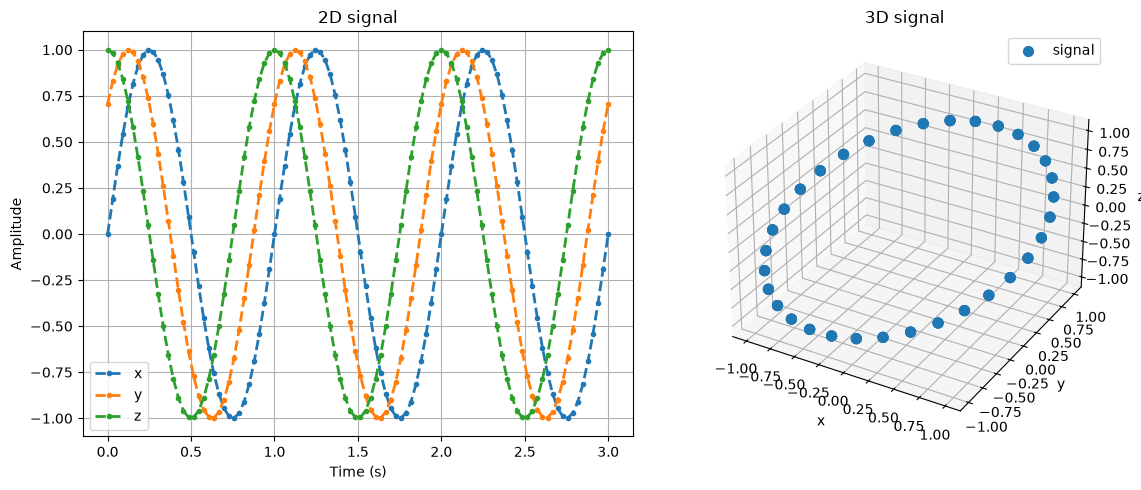

In [6]:
# Display the requested information
print("t.shape =", time.shape)
print("s.shape =", signal.shape)
print("phase_shift = 0.25 pi")

fig = plt.figure(figsize=(12, 5))

# 2D plot
ax1 = fig.add_subplot(1, 2, 1)

ax1.plot(time[:, 0], signal[:, 0], 'o--', markersize=3, linewidth=2, label='x')
ax1.plot(time[:, 0], signal[:, 1], 'o--', markersize=3, linewidth=2, label='y')
ax1.plot(time[:, 0], signal[:, 2], 'o--', markersize=3, linewidth=2, label='z')

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.set_title("2D signal")
ax1.legend()
ax1.grid()

# 3D plot
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

ax2.scatter(# to get a scatter plot
    signal[:, 0],
    signal[:, 1],
    signal[:, 2],
    s=50,
    label="signal"
)

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.set_title("3D signal")
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Estimate the time derivative of the signal

### 1. Maths formula

$$
s(t) = A\sin(2\pi f t+\phi)
$$

The time derivative is:

$$
\frac{ds(t)}{dt}=A\,2\pi f\cos(2\pi f t+\phi)
$$

For $A=1$, $f=1$ Hz and $\phi=0$:

$$
\frac{ds(t)}{dt}=2\pi\cos(2\pi t)
$$

### 2. Equation along each axis

The time derivative of signal along each axis is:

$$
\frac{dx(t)}{dt}=2\pi\cos(2\pi t)
$$

$$
\frac{dy(t)}{dt}=2\pi\cos\left(2\pi t+\frac{\pi}{4}\right)
$$

$$
\frac{dz(t)}{dt}=2\pi\cos\left(2\pi t+\frac{\pi}{2}\right)
$$

### 3. Difference between methods to compute time derivative of a signal

#### Forward difference:

The forward difference uses the current sample and the next sample to
approximate the time derivative:

$$
\frac{ds(t_i)}{dt}
\approx
\frac{s(t_{i+1})-s(t_i)}
{t_{i+1}-t_i}
$$

It uses information from the future sample only.


#### Central difference:

The central difference uses the previous and the next samples around
the current sample:

$$
\frac{ds(t_i)}{dt}
\approx
\frac{s(t_{i+1})-s(t_{i-1})}
{t_{i+1}-t_{i-1}}
$$

It uses information from both sides of the current sample.

#### Reference:
https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter20.02-Finite-Difference-Approximating-Derivatives.html